# Non-Linear Directional Anomaly Detection
## Deep AutoEncoders with Asymmetric Residual Filtering and Adaptive Thresholding

### 1. Neural Reconstruction and Residual Polarity
The core of this system is an **AutoEncoder (AE)**. Unlike linear models, the AE learns a non-linear manifold of the "Normal Operating State." We define the **Reconstruction Residual** ($r$) as:
$$r_i = X_i - \hat{X}_i$$

To handle **Directional Sensitivity**, we apply a transformation based on the failure mode of interest ($D_i$):
* **Positive ($D_i=1$):** $E_{dir, i} = \max(0, r_i)$
* **Negative ($D_i=-1$):** $E_{dir, i} = \max(0, -r_i)$
* **Bilateral ($D_i=0$):** $E_{dir, i} = |r_i|$

### 2. Standardization and Adaptive Thresholding
Each directional error is standardized by the standard deviation ($\sigma$) of the baseline period. The **Global Risk Score** is then compared against an **Adaptive Threshold** ($T_t$):
$$T_t = \text{SMA}_{window}(RiskScore) + k \cdot \text{StdDev}_{baseline}(RiskScore)$$
This allows the threshold to follow slow process drifts (via the Simple Moving Average) while maintaining a sensitivity linked to the original healthy state.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Configuration Map for Directionality
# 'pos' (actual > pred), 'neg' (actual < pred), 'both' (any deviation)
anomaly_config = {
    'S1': 'pos',
    'S2': 'both',
    'S3': 'neg',
    'S4': 'both',
    'S5': 'both'
}

# 2. Neural Network Definition
class DeepAutoEncoder(nn.Module):
    def __init__(self, input_dim):
        super(DeepAutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 3) # Latent bottleneck
        )
        self.decoder = nn.Sequential(
            nn.Linear(3, 8),
            nn.ReLU(),
            nn.Linear(8, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

print("System configured for Directional Neural Reconstruction.")

System configured for Directional Neural Reconstruction.


### 3. Data Preparation and Anomaly Injection
We generate 1500 samples of non-linearly correlated data. To test the **Directional Filter**, we inject two types of anomalies:
1.  **S1 (Positive Care):** We inject a positive drift (detected) and a negative dip (should be ignored).
2.  **S3 (Negative Care):** We inject a negative dip (detected) and a positive surge (should be ignored).

We use a **StandardScaler** to normalize inputs before feeding them into the Neural Network.

In [2]:
np.random.seed(42)
n_samples = 1500
t = np.linspace(0, 100, n_samples)
base = 10 * np.sin(t/5) + 50 

data = pd.DataFrame({
    'S1': base + np.random.normal(0, 0.5, n_samples),
    'S2': base**1.1 + np.random.normal(0, 0.5, n_samples),
    'S3': np.sqrt(base) * 10 + np.random.normal(0, 0.5, n_samples),
    'S4': base * 0.5 + 20 + np.random.normal(0, 0.5, n_samples),
    'S5': base + np.cos(t/2) * 5 + np.random.normal(0, 0.5, n_samples)
})

# Anomaly S1: care only about 'pos'
data.loc[400:500, 'S1'] += 15 # Detected
data.loc[550:600, 'S1'] -= 15 # Ignored

# Anomaly S3: care only about 'neg'
data.loc[800:900, 'S3'] -= 12 # Detected
data.loc[950:1000, 'S3'] += 12 # Ignored

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
train_tensor = torch.FloatTensor(data_scaled[:400]) # First 400 as healthy baseline
full_tensor = torch.FloatTensor(data_scaled)

### 4. Neural Network Optimization and Training Logic

The training phase aims to find the optimal parameters $\theta$ (weights) and $\phi$ (biases) that minimize the discrepancy between the input and its reconstruction. 

#### 4.1 Loss Function: Mean Squared Error (MSE)
We define the objective function as the average of the squared Euclidean distances between the original scaled vector $x$ and the reconstructed vector $\hat{x}$ for all $N$ samples in the healthy baseline:

$$\mathcal{L}(\theta, \phi) = \frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{M} (x_{i,j} - \hat{x}_{i,j})^2$$

Where:
* $N$ is the number of training samples (baseline).
* $M$ is the number of sensors (input dimensions).
* $\hat{x}$ is the output of the decoder: $\hat{x} = g_\theta(f_\phi(x))$.

#### 4.2 Optimization: Stochastic Gradient Descent (Adam)
We use the **Adam (Adaptive Moment Estimation)** optimizer. Adam computes adaptive learning rates for each parameter by estimating the first and second moments of the gradients:

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$

Where $g_t$ is the gradient at time $t$. This ensures faster convergence in the non-convex landscape of the neural network's loss surface.

#### 4.3 Training Protocol
1. **Forward Pass:** The data is passed through the Encoder to the latent bottleneck and then through the Decoder.
2. **Loss Calculation:** The MSE is computed against the input.
3. **Backward Pass:** Gradients are calculated via backpropagation using the chain rule.
4. **Weight Update:** Parameters are updated to reduce the reconstruction error.

In [3]:
model = DeepAutoEncoder(input_dim=5)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

epochs = 250
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(train_tensor)
    loss = criterion(output, train_tensor)
    loss.backward()
    optimizer.step()

print(f"Final Training Loss: {loss.item():.6f}")

Final Training Loss: 0.022335


### 5. Post-Processing: Directional Filtering and Stochastic Adaptation

Once the AutoEncoder (AE) is trained, we use the **Reconstruction Error** to quantify the deviation from the learned manifold. However, a raw error is insufficient for high-reliability industrial monitoring. We must apply two critical transformations:

#### 5.1 Directional Residual Transformation
For each sensor $j$, we define the raw residual $r_{t,j}$ at time $t$ as the difference between the observed value $x$ and the reconstructed value $\hat{x}$:
$$r_{t,j} = x_{t,j} - \hat{x}_{t,j}$$

To satisfy the **Asymmetric Risk Profile**, we apply a Directional Filter $\mathcal{F}$ based on the predefined configuration $D_j \in \{\text{pos, neg, both}\}$:
$$E_{t,j} = 
\begin{cases} 
\max(0, r_{t,j}) & \text{if } D_j = \text{pos} \\
\max(0, -r_{t,j}) & \text{if } D_j = \text{neg} \\
|r_{t,j}| & \text{if } D_j = \text{both}
\end{cases}$$

#### 5.2 Sigma-Scaling (Statistical Normalization)
Each filtered error is normalized using the standard deviation $\sigma$ calculated during the **Healthy Baseline** period ($T_{base}$):
$$S_{t,j} = \frac{E_{t,j}}{3 \cdot \sigma_{j, base}}$$
This ensures that a value of $1.0$ represents a $3\sigma$ deviation, providing a universal scale across heterogeneous sensors.

#### 5.3 Stochastic Adaptive Thresholding
To account for non-stationary noise and slow process drifts, we implement a **Simple Moving Average (SMA)**-based threshold. The threshold $T_t$ adapts to the local mean of the Global Risk Score ($RS_t$) while maintaining a sensitivity margin based on the baseline volatility:
$$T_t = \frac{1}{w} \sum_{i=t-w}^{t} RS_i + k \cdot \sigma_{RS, base}$$
Where:
* $w$ is the sliding window size (e.g., 50 samples).
* $k$ is the sensitivity multiplier (typically 3).
* $\sigma_{RS, base}$ is the standard deviation of the Risk Score during the baseline period.

In [4]:
model.eval()
with torch.no_grad():
    reconstructed = model(full_tensor).numpy()

# 1. Directional Filtering
residuals = data_scaled - reconstructed
directional_errors = pd.DataFrame(index=data.index)

for i, col in enumerate(data.columns):
    res = residuals[:, i]
    mode = anomaly_config[col]
    
    if mode == 'pos': filtered = np.maximum(0, res)
    elif mode == 'neg': filtered = np.maximum(0, -res)
    else: filtered = np.abs(res)
    
    # Sigma Scaling (using first 400 samples)
    baseline_std = filtered[:400].std() if filtered[:400].std() != 0 else 1
    directional_errors[f'Err_{col}'] = filtered / (baseline_std * 3)

# 2. Risk Score and Adaptive Threshold
risk_score = directional_errors.sum(axis=1)
data['Risk_Score'] = MinMaxScaler().fit_transform(risk_score.values.reshape(-1,1))

# Threshold: 50-sample moving average + Baseline Sensitivity
baseline_volatility = data['Risk_Score'].iloc[:400].std()
data['Thresh'] = data['Risk_Score'].rolling(50).mean() + (3 * baseline_volatility)
data['Thresh'] = data['Thresh'].fillna(data['Thresh'].dropna().iloc[0])

print("Directional Risk and Adaptive Threshold finalized.")

Directional Risk and Adaptive Threshold finalized.


### 6. Temporal Debouncing (Alarm Logic)
To prevent "chatter" or false alarms from momentary spikes, we implement:
* **On-Delay:** Risk must exceed the threshold for $N$ consecutive samples to trigger an alarm.
* **Off-Delay:** Risk must drop below the threshold for $M$ consecutive samples to clear the alarm.

In [5]:
on_delay, off_delay = 5, 5
counter, current_state = 0, False
alarms = []

for i in range(len(data)):
    is_above = data['Risk_Score'].iloc[i] > data['Thresh'].iloc[i]
    
    if not current_state:
        if is_above:
            counter += 1
            if counter >= on_delay:
                current_state, counter = True, 0
        else: counter = 0
    else:
        if not is_above:
            counter += 1
            if counter >= off_delay:
                current_state, counter = False, 0
        else: counter = 0
    alarms.append(current_state)

data['Alarm'] = alarms
print(f"Detected {data['Alarm'].sum()} alarm samples.")

Detected 100 alarm samples.


### 7. Results and Root Cause Analysis
The visualization demonstrates the effectiveness of the directional filter. The "ignored" spikes do not trigger the alarm. The stacked area identifies which sensor is the primary driver of the reconstruction failure.

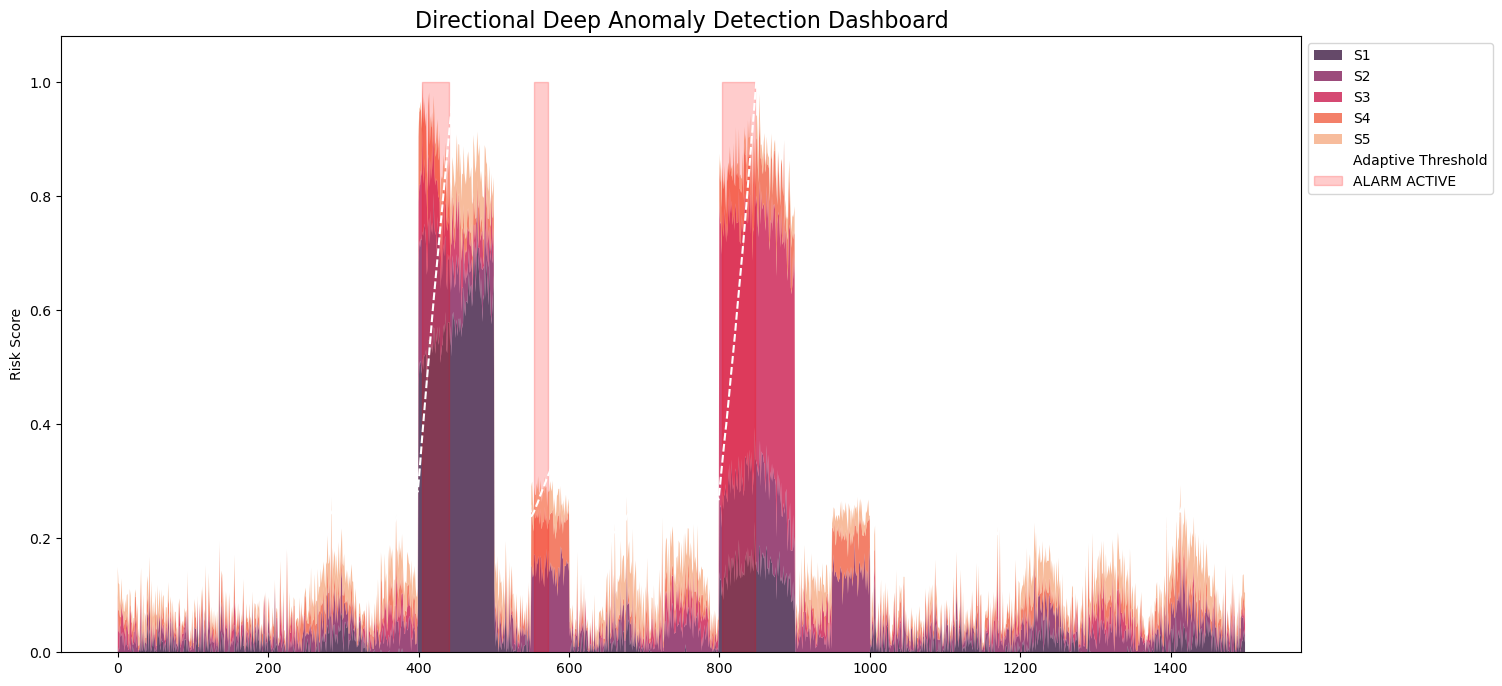

In [6]:
# Contribution calculation
total_err = directional_errors.sum(axis=1).replace(0, 1e-9)
norm_cont = directional_errors.div(total_err, axis=0).multiply(data['Risk_Score'], axis=0)

plt.figure(figsize=(16, 8))
plt.stackplot(data.index, [norm_cont[c] for c in norm_cont.columns], 
              labels=data.columns, alpha=0.8, colors=sns.color_palette("rocket", 5))

plt.plot(data['Thresh'], color='white', linestyle='--', label='Adaptive Threshold')
plt.fill_between(data.index, 0, 1, where=data['Alarm'], color='red', alpha=0.2, label='ALARM ACTIVE')

plt.title('Directional Deep Anomaly Detection Dashboard', fontsize=16)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.ylabel('Risk Score')
plt.style.use('dark_background')
plt.show()